# Lo spettro di emissione di un corpo nero

In [1]:
# python library imports

import random
import numpy as np
import matplotlib.pyplot as plt
from math import floor, exp
from scipy.stats import t as tstudent
from scipy.stats import norm
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL

from lib import generate_TAC, generate_TCL_ms, sturges_c, set_range, sezioneAureaMin
from stats import stats
from planck import u_lam, find_maximum

## Punto 1

Si disegni la funzione della legge di Plank alla temperatura di 2000 K sull'intervallo di lunghezze d'onda compreso fra 0.1 e 5~$\mu$m e se ne determini il valore massimo $\lambda_{M}$ utilizzando la tecnica della sezione aurea, definendo tutte le funzioni necessarie in librerie.

In [2]:
T = 2000 #K
lam_min = 1e-7 # m
lam_max = 5e-6 # m

f = lambda x : -1 * u_lam (x, T)

maximum = sezioneAureaMin (f, lam_min, lam_max, 1e-8)
print ('The maximum is found at ', maximum, ' m wavelength')

The maximum is found at  1.451124263153119e-06  m wavelength


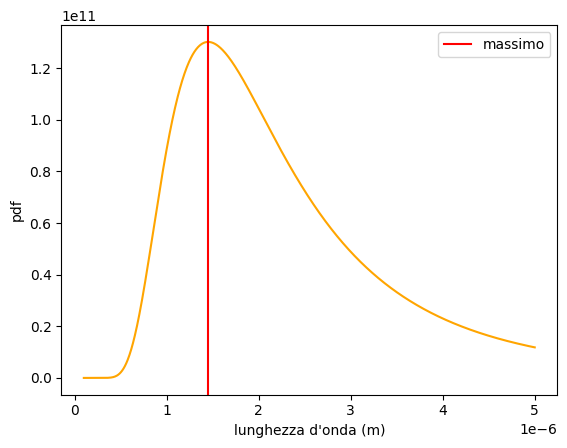

In [3]:
f = lambda x : u_lam (x, T)
x_coord = np.linspace (lam_min, lam_max, 1000)
y_coord = f(x_coord)

fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.plot (x_coord, y_coord,
         color = 'orange',
        )
plt.axvline (x = maximum,
         color = 'red',
         label = 'massimo',
        )
ax.set_xlabel ("lunghezza d'onda (m)")
ax.set_ylabel ("pdf")
ax.legend ()

## Punto 2

Trattando la funzione della legge di Plank alla stregua di una distribuzione di densit\`a di probabilit\`a, si generino 10_000 numeri pseudo-casuali che ne seguano la distribuzione nello stesso intervallo di lunghezze d'onda, 
si disegni l'istogramma del campione scegliendo appropriatamente estremi e binnaggio e se ne calcolino - utilizzando funzioni implementate esplicitamente - i momenti principali.

In [4]:
sample = generate_TAC (f, lam_min, lam_max, f (maximum), 10000)

In [5]:
plank_stats = stats (sample)
media = plank_stats.mean ()
sigma = plank_stats.sigma ()
print (f'media: {media:.3g}')
print (f'sigma: {sigma:.3g}')
print (f'asimm: {plank_stats.skewness ():.3g}')
print (f'kurt: {plank_stats.kurtosis ():.3g}')

media: 2.16e-06
sigma: 9.72e-07
asimm: 0.834
kurt: 0.086


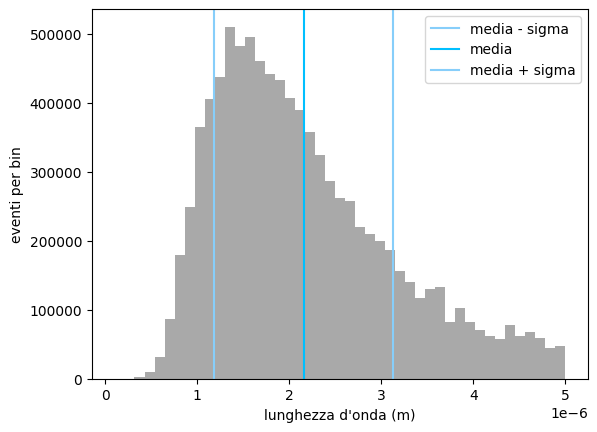

In [6]:
N_bins = sturges_c (sample)
bin_edges = np.linspace (lam_min, lam_max, N_bins)

fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.hist (sample,
         bins = bin_edges,
         color = 'darkgray',
         density = True,
        )
plt.axvline (x = media-sigma,
         color = 'lightskyblue',
         label = 'media - sigma',
        )
plt.axvline (x = media,
         color = 'deepskyblue',
         label = 'media',
        )
plt.axvline (x = media+sigma,
         color = 'lightskyblue',
         label = 'media + sigma',
        )
ax.set_xlabel ("lunghezza d'onda (m)")
ax.set_ylabel ("eventi per bin")

ax.legend ()

## Punto 3

Si determini il massimo della distribuzione, con relativo errore, del campione facendo un fit Gaussiano in un appropriato intervallo definito intorno alla media del campione in funzione dei momenti della distribuzione.
Dopo aver controllato il successo del fit, si stampi il risultato a schermo.

### fit con la massima verosimiglianza

In [7]:
# the fitting function
def model (bin_edges, N_signal, mu, sigma):
    return N_signal * norm.cdf (bin_edges, mu, sigma) 

x_range = (media - 1.5 * sigma, media)
N_bins_fit = int (N_bins * (x_range[1] - x_range[0]) / (lam_max - lam_min))
bin_content_fit, bin_edges_fit = np.histogram (sample, bins = N_bins_fit, range = x_range)

my_cost_func = ExtendedBinnedNLL (bin_content_fit, bin_edges_fit, model)

# the fitting algoritm
my_minuit = Minuit (my_cost_func, 
                    N_signal = len (sample), mu = media, sigma = sigma, # signal input parameters
                   )
my_minuit.migrad ()
my_minuit.minos ()
display (my_minuit)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 45.89 (χ²/ndof = 4.6)      │              Nfcn = 290              │
│ EDM = 5.31e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal │  7.38e3   │  0.17e3   │  -0.17e3   │   0.18e3   │         │         │       │
│ 1 │ mu       │ 1.595e-6  │ 0.014e-6  │ -0.014e-6  │  0.015e-6  │         │         │       │
│ 2 │ sigma    │ 0.573e-6  │ 0.018e-6  │ -0.017e-6  │  0.018e-6  │         │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │       N_signal        │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.17e3  │  0.18e3   │ -0.014e-6 │ 0.015e-6  │ -0.017e-6 │ 0.018e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────────┬────────────────────────────────────────────────────┐
│          │         N_signal               mu            sigma │
├──────────┼────────────────────────────────────────────────────┤
│ N_signal │         2.99e+04 1.39721839922e-6 2.48360607522e-6 │
│       mu │ 1.39721839922e-6         1.98e-16         0.14e-15 │
│    sigma │ 2.48360607522e-6         0.14e-15         3.11e-16 │
└──────────┴────────────────────────────────────────────────────┘

In [8]:
if my_minuit.valid: print ('Il fit ha raggiunto la convergenza')

maximum_fit = my_minuit.values['mu']
maximum_fit_error = my_minuit.errors['mu']

print (f'massimo trovato con il fit: {maximum_fit:.3g}')
print (f'con errore: {maximum_fit_error:.3g}')

Il fit ha raggiunto la convergenza
massimo trovato con il fit: 1.59e-06
con errore: 1.41e-08


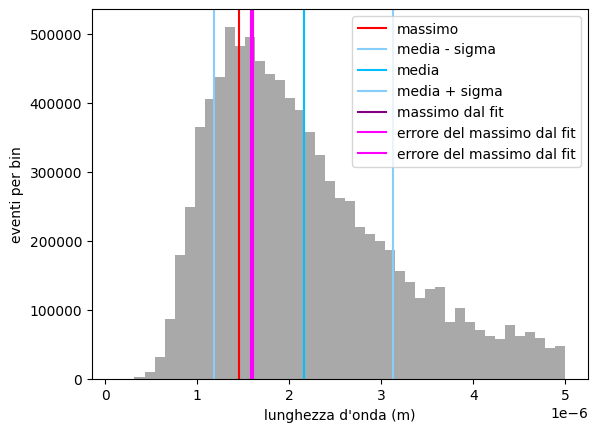

In [9]:
fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.hist (sample,
         bins = bin_edges,
         color = 'darkgray',
         density = True,
        )
plt.axvline (x = maximum,
         color = 'red',
         label = 'massimo',
        )
plt.axvline (x = media-sigma,
         color = 'lightskyblue',
         label = 'media - sigma',
        )
plt.axvline (x = media,
         color = 'deepskyblue',
         label = 'media',
        )
plt.axvline (x = media+sigma,
         color = 'lightskyblue',
         label = 'media + sigma',
        )
plt.axvline (x = maximum_fit,
         color = 'purple',
         label = 'massimo dal fit',
        )
plt.axvline (x = maximum_fit - maximum_fit_error,
         color = 'fuchsia',
         label = 'errore del massimo dal fit',
        )
plt.axvline (x = maximum_fit + maximum_fit_error,
         color = 'fuchsia',
         label = 'errore del massimo dal fit',
        )
ax.set_xlabel ("lunghezza d'onda (m)")
ax.set_ylabel ("eventi per bin")
ax.legend ()

## Punto 4

Utilizzando la tecnica dei \textit{toy experiment}, si disegni l'istogramma dello stimatore del massimo appena costruito, si valuti la bont\`a della stima dell'incertezza associata e si stampi a schermo il suo errore quadratico medio, o \textit{mean square error}.

In [10]:
N_toys = 1000

maxima = []
maxima_error = []

# loop over toy experiments
i_toy = 0
while i_toy < N_toys :
    # genera il campione
    sample = generate_TAC (f, lam_min, lam_max, f(maximum), 1000)
    isValid, max_fit, max_fit_error = find_maximum (sample, model, lam_min, lam_max)
    if not isValid : 
        print ('fit failed')
        continue
    
    maxima.append (max_fit)
    maxima_error.append (max_fit_error)

    i_toy += 1
    if i_toy % 100 == 0 : print (i_toy)
# loop over toy experiments



print ('DONE')

100
200
300
400
500
600
700
800
900
1000
DONE


1000
The mean square error associated to the maximum estimate is : 1.884e-14 m


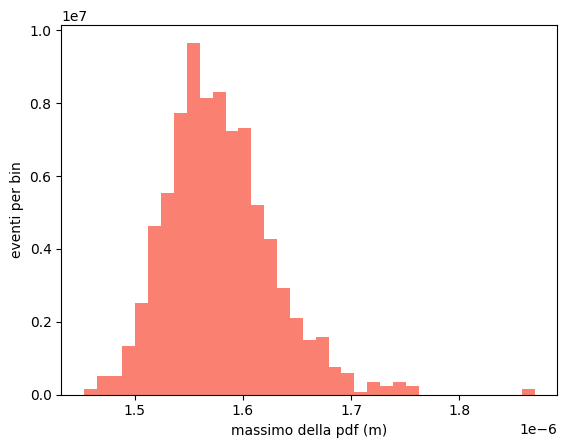

In [11]:
print (len (maxima))

fig, ax = plt.subplots (nrows = 1, ncols = 1)

bin_edges = np.linspace (min (maxima), max (maxima), sturges_c (maxima))

ax.hist (maxima,
         bins = sturges_c (maxima),
         color = 'salmon',
         density = True,
        )
ax.set_xlabel ("massimo della pdf (m)")
ax.set_ylabel ("eventi per bin")

stats_maxima = stats (maxima)
estimate_bias = stats_maxima.mean () - maximum
estimate_sigma = stats_maxima.sigma () 

MSE = estimate_bias**2 + estimate_sigma**2

print (f'The mean square error associated to the maximum estimate is : {MSE:.4g} m')


## Punto 5

Si determini come varia il bias nella stima del massimo in funzione del numero di fotoni raccolti, da 10 a 10,000. Lo stimatore è asintoticamente non distorto?

In [12]:
biases = []
events = []

N_events = 10
while N_events <= 10000:
    maxima = []
    maxima_error = []

    print ('--> N_events = ', N_events)
    # loop over toy experiments
    i_toy = 0
    failures = 0
    while i_toy < N_toys :
        # genera il campione
        sample = generate_TAC (f, lam_min, lam_max, f(maximum), N_events)
        isValid, max_fit, max_fit_error = find_maximum (sample, model, lam_min, lam_max)
        if not isValid : 
            failures += 1
            continue
        
        maxima.append (max_fit)
        maxima_error.append (max_fit_error)
    
        i_toy += 1
        if i_toy % 100 == 0 : print ('toy: ', i_toy)
    # loop over toy experiments

    if failures > 0 : print ('\nfit failures:', failures)
    stats_maxima = stats (maxima)
    estimate_bias = stats_maxima.mean () - maximum
    biases.append (estimate_bias)
    events.append (N_events)
    N_events *= 3



--> N_events =  10
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000

fit failures: 363
--> N_events =  30
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000

fit failures: 261
--> N_events =  90
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000

fit failures: 41
--> N_events =  270
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000

fit failures: 9
--> N_events =  810
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000
--> N_events =  2430
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000
--> N_events =  7290
toy:  100
toy:  200
toy:  300
toy:  400
toy:  500
toy:  600
toy:  700
toy:  800
toy:  900
toy:  1000


Text(0, 0.5, 'bias del fit')

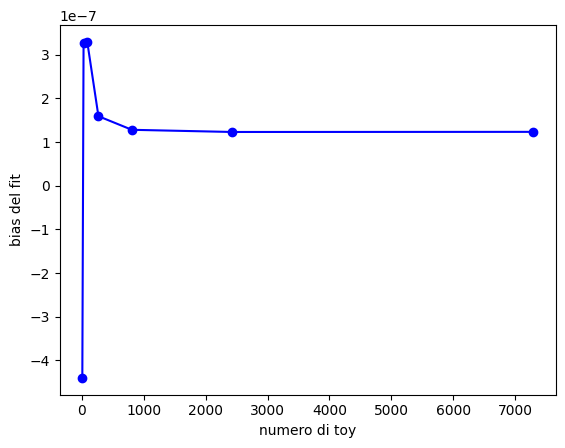

In [13]:
fig, ax = plt.subplots (nrows = 1, ncols = 1)

ax.plot (events, biases, 'b-o')
ax.set_xlabel ("numero di toy")
ax.set_ylabel ("bias del fit")


